In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    Birch,
    SpectralClustering
)

from sklearn.mixture import GaussianMixture

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

**Upload Dataset**

In [25]:
from google.colab import files

uploaded = files.upload()

Saving Wholesale customers data.csv to Wholesale customers data (1).csv


**Load Dataset**

In [26]:
df = pd.read_csv("Wholesale customers data.csv")

print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


**Dataset Information**

In [27]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicates")
print(df.duplicated().sum())

print("\nShape")
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None

Missing Values
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Duplicates
0

Shape
(440, 8)


**Statistical Summary**

In [28]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


**Data Cleaning**

In [29]:
imputer = SimpleImputer(strategy="median")

df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

df = df.drop_duplicates()

print(df.shape)

(440, 8)


**Feature Scaling**

In [30]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print(X_scaled.shape)

(440, 8)


**PCA=A dimensionality reduction technique that transforms data into fewer components while retaining most of the information.**

In [31]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.38750123 0.22374588]


**PCA Visualization**

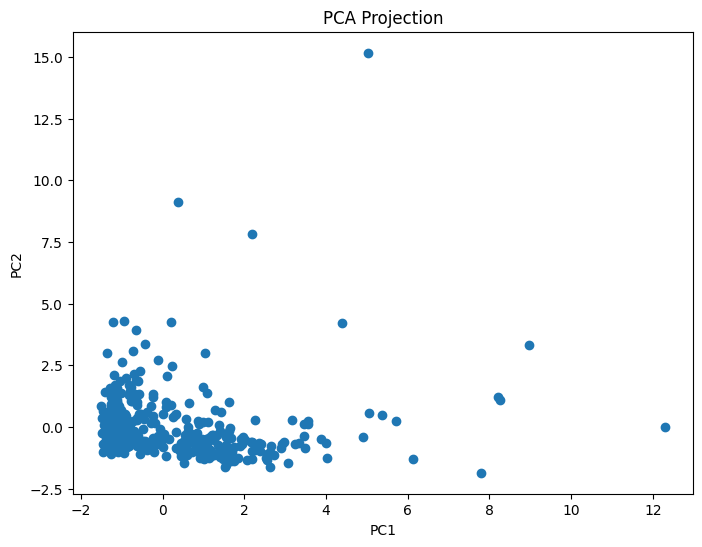

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Elbow Method =A method for finding the optimal number of clusters by selecting the point where adding more clusters provides diminishing improvement. **

In [33]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

**Elbow Graph**

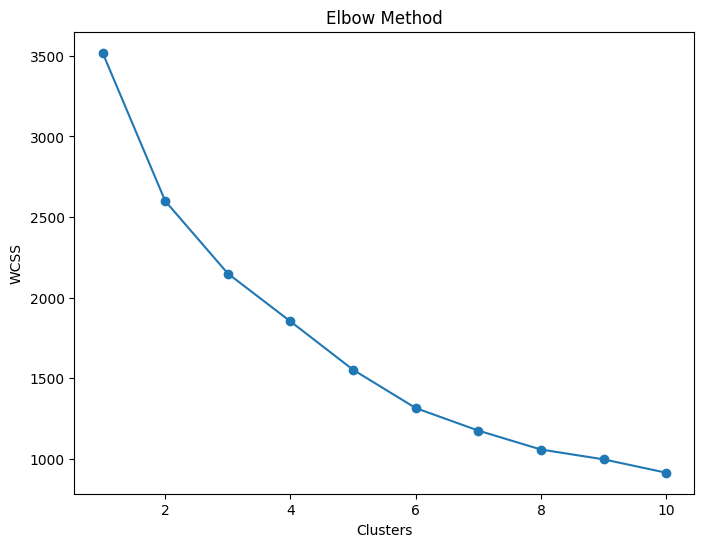

In [34]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

**KMeans=A clustering algorithm that groups data into K clusters by minimizing the distance between data points and cluster centroids.**

In [35]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans"] = kmeans_labels

print(
    silhouette_score(
        X_scaled,
        kmeans_labels
    )
)

0.35292393966569646


**KMeans Visualization**

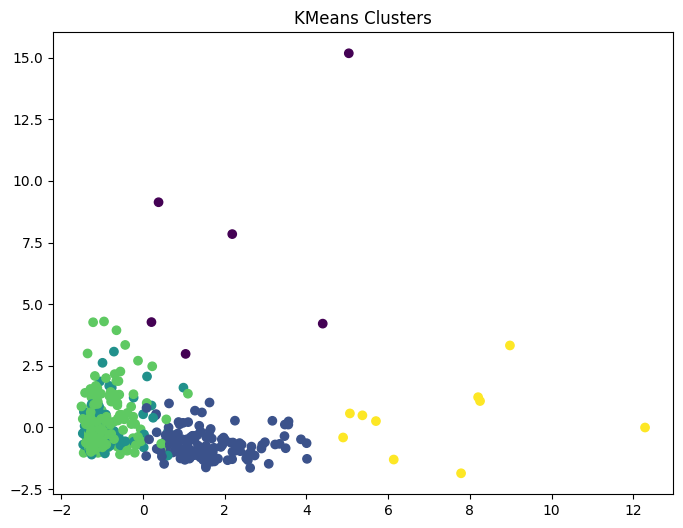

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels
)

plt.title("KMeans Clusters")
plt.show()

**Hierarchical Clustering=A clustering technique that builds a hierarchy of clusters by successively merging or splitting groups of data points.**

In [37]:
hierarchical = AgglomerativeClustering(
    n_clusters=5
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

df["Hierarchical"] = hierarchical_labels

print(
    silhouette_score(
        X_scaled,
        hierarchical_labels
    )
)

0.3178066486005939


**DBSCAN=(Density-Based Spatial Clustering of Applications with Noise) – A density-based clustering algorithm that identifies clusters and detects outliers in the data.**

In [38]:
dbscan = DBSCAN(
    eps=1.2,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN"] = dbscan_labels

print(np.unique(dbscan_labels))

[-1  0  1  2  3  4  5]


**GMM=(Gaussian Mixture Model) – A probabilistic clustering algorithm that assumes data is generated from a mixture of multiple Gaussian distributions**

In [39]:
gmm = GaussianMixture(
    n_components=5,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)

df["GMM"] = gmm_labels

print(
    silhouette_score(
        X_scaled,
        gmm_labels
    )
)

0.34551348708034596


**Birch=(Balanced Iterative Reducing and Clustering using Hierarchies) – An efficient clustering algorithm designed for large datasets by building a hierarchical clustering tree.**

In [40]:
birch = Birch(
    n_clusters=5
)

birch_labels = birch.fit_predict(X_scaled)

df["Birch"] = birch_labels

print(
    silhouette_score(
        X_scaled,
        birch_labels
    )
)

0.3631732423110055


**Spectral Clustering =A clustering method that uses graph theory and eigenvalues to identify complex cluster structures in data.**

In [41]:
spectral = SpectralClustering(
    n_clusters=5,
    random_state=42
)

spectral_labels = spectral.fit_predict(X_scaled)

df["Spectral"] = spectral_labels

print(
    silhouette_score(
        X_scaled,
        spectral_labels
    )
)

0.8263511877226627


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


**t-SNE=A technique used to visualize high-dimensional data in 2D or 3D by keeping similar data points close together.**

In [19]:
tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

**t-SNE Visualization**

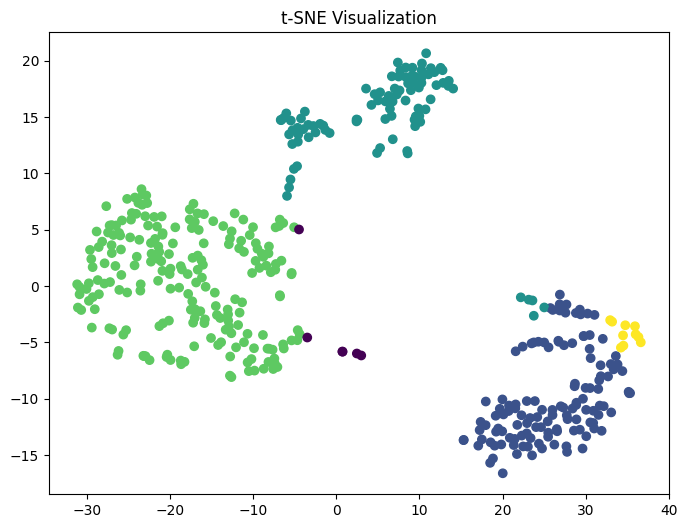

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=kmeans_labels
)

plt.title("t-SNE Visualization")
plt.show()

**Isolation Forest=An anomaly detection algorithm that identifies outliers by isolating observations through random partitioning.**

In [21]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

outliers = iso.fit_predict(X_scaled)

df["Outlier"] = outliers

print(
    df["Outlier"].value_counts()
)

Outlier
 1    418
-1     22
Name: count, dtype: int64


**Model Comparison**

In [22]:
results = pd.DataFrame({

    "Algorithm":[
        "KMeans",
        "Hierarchical",
        "GMM",
        "Birch",
        "Spectral"
    ],

    "Silhouette":[

        silhouette_score(
            X_scaled,
            kmeans_labels
        ),

        silhouette_score(
            X_scaled,
            hierarchical_labels
        ),

        silhouette_score(
            X_scaled,
            gmm_labels
        ),

        silhouette_score(
            X_scaled,
            birch_labels
        ),

        silhouette_score(
            X_scaled,
            spectral_labels
        )
    ]
})

results.sort_values(
    by="Silhouette",
    ascending=False
)

,Algorithm,Silhouette
4,Spectral,0.826351
3,Birch,0.363173
0,KMeans,0.352924
2,GMM,0.345513
1,Hierarchical,0.317807


**Model Evaluation & Comparison**

In [42]:
# ==========================
# MODEL COMPARISON
# ==========================

results = []

# KMeans
results.append([
    "KMeans",
    silhouette_score(X_scaled, kmeans_labels),
    davies_bouldin_score(X_scaled, kmeans_labels),
    calinski_harabasz_score(X_scaled, kmeans_labels)
])

# Hierarchical
results.append([
    "Hierarchical",
    silhouette_score(X_scaled, hierarchical_labels),
    davies_bouldin_score(X_scaled, hierarchical_labels),
    calinski_harabasz_score(X_scaled, hierarchical_labels)
])

# GMM
results.append([
    "GMM",
    silhouette_score(X_scaled, gmm_labels),
    davies_bouldin_score(X_scaled, gmm_labels),
    calinski_harabasz_score(X_scaled, gmm_labels)
])

# Birch
results.append([
    "Birch",
    silhouette_score(X_scaled, birch_labels),
    davies_bouldin_score(X_scaled, birch_labels),
    calinski_harabasz_score(X_scaled, birch_labels)
])

# Spectral
results.append([
    "Spectral",
    silhouette_score(X_scaled, spectral_labels),
    davies_bouldin_score(X_scaled, spectral_labels),
    calinski_harabasz_score(X_scaled, spectral_labels)
])

comparison_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz"
    ]
)

comparison_df = comparison_df.sort_values(
    by="Silhouette",
    ascending=False
)

print(comparison_df)

      Algorithm  Silhouette  Davies_Bouldin  Calinski_Harabasz
4      Spectral    0.826351        0.121685          48.882614
3         Birch    0.363173        0.794459         115.771436
0        KMeans    0.352924        1.148050         137.952305
2           GMM    0.345513        1.184001         128.431002
1  Hierarchical    0.317807        0.895960         123.506068


**Print Best Model Automatically**

In [43]:
best_model = comparison_df.iloc[0]

print("\n" + "="*50)
print("BEST MODEL")
print("="*50)

print("Algorithm :", best_model["Algorithm"])
print("Silhouette Score :", round(best_model["Silhouette"],4))
print("Davies-Bouldin :", round(best_model["Davies_Bouldin"],4))
print("Calinski-Harabasz :", round(best_model["Calinski_Harabasz"],2))


BEST MODEL
Algorithm : Spectral
Silhouette Score : 0.8264
Davies-Bouldin : 0.1217
Calinski-Harabasz : 48.88


**Comparison Visualization**

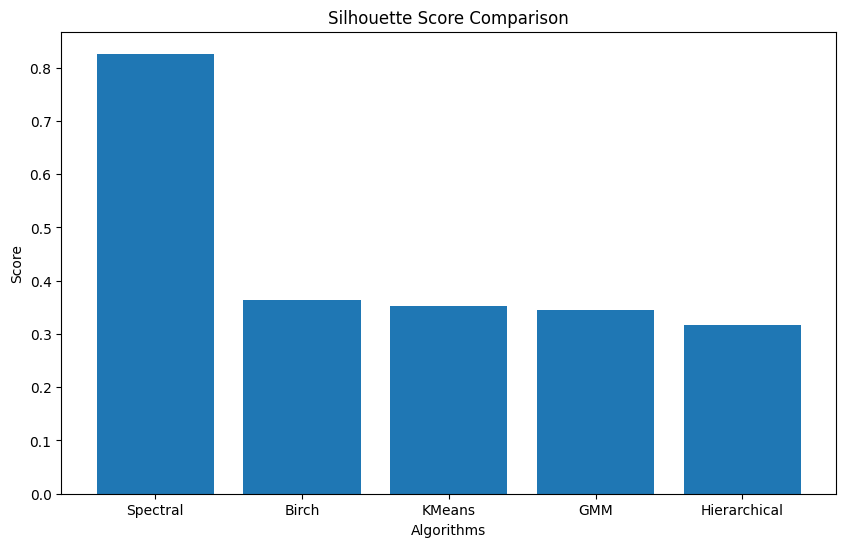

In [44]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison_df["Algorithm"],
    comparison_df["Silhouette"]
)

plt.title("Silhouette Score Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Score")

plt.show()

**KMeans diagram**

In [46]:
#visualizing every model

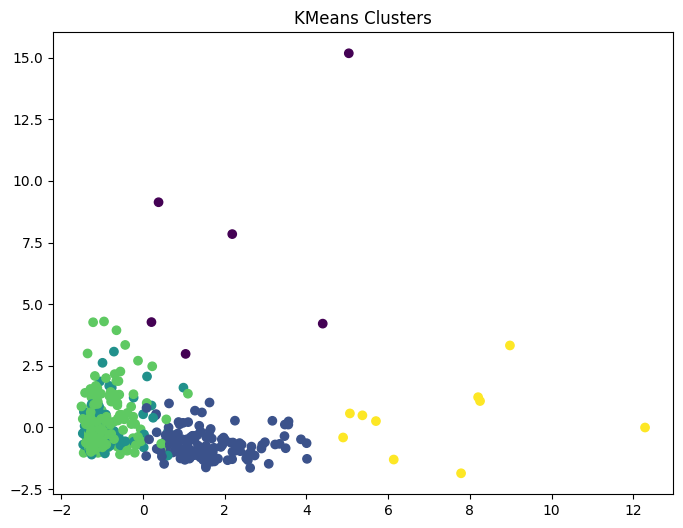

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels
)

plt.title("KMeans Clusters")
plt.show()

**Hierarchical diagram**

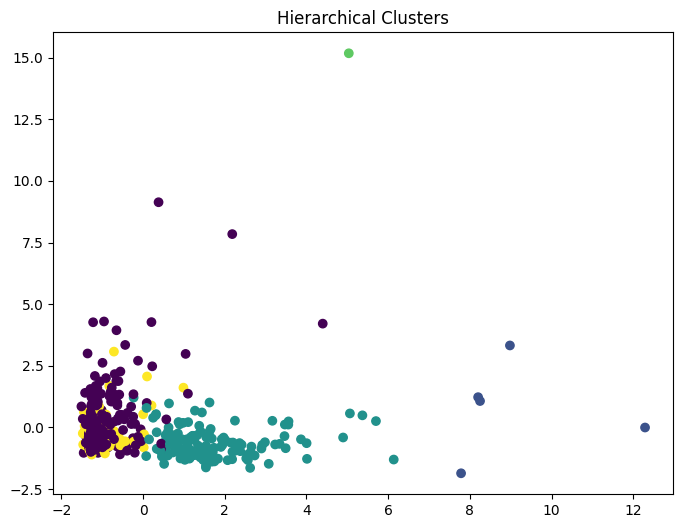

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hierarchical_labels
)

plt.title("Hierarchical Clusters")
plt.show()

**DBSCAN diagram**

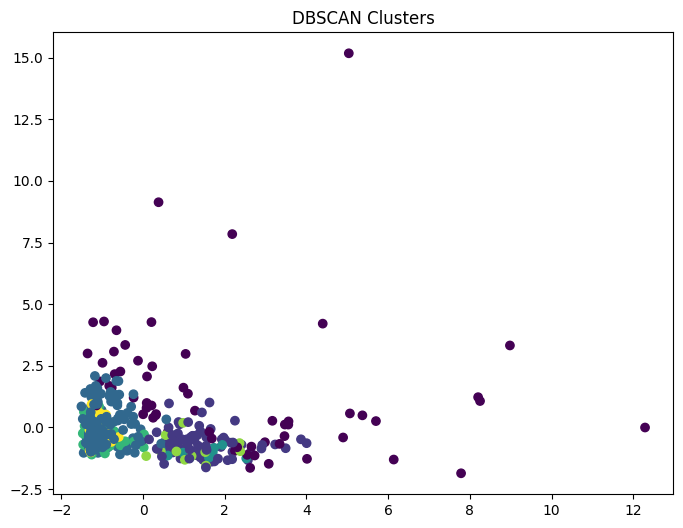

In [49]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels
)

plt.title("DBSCAN Clusters")
plt.show()

**GMM diagram**

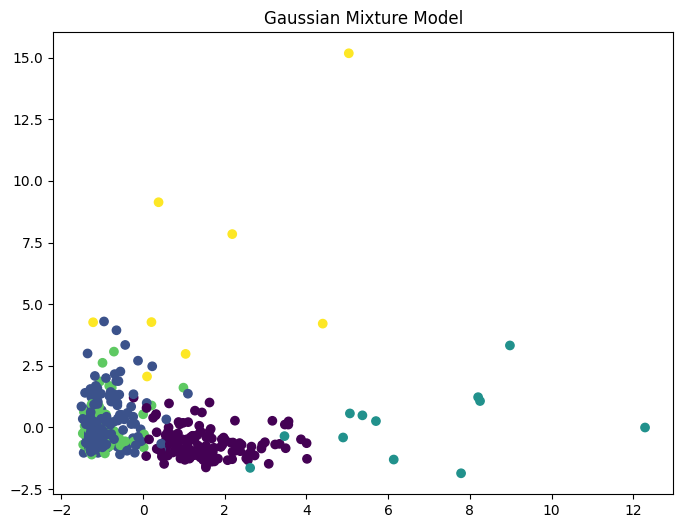

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=gmm_labels
)

plt.title("Gaussian Mixture Model")
plt.show()

**Birch diagram**

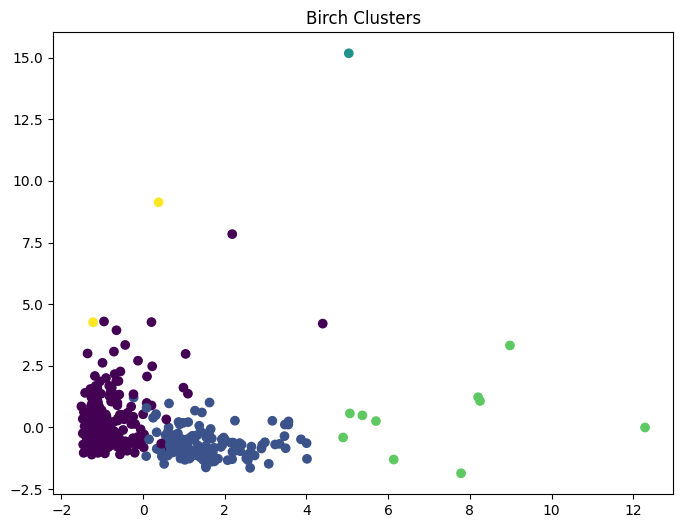

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=birch_labels
)

plt.title("Birch Clusters")
plt.show()

**Spectral diagram**

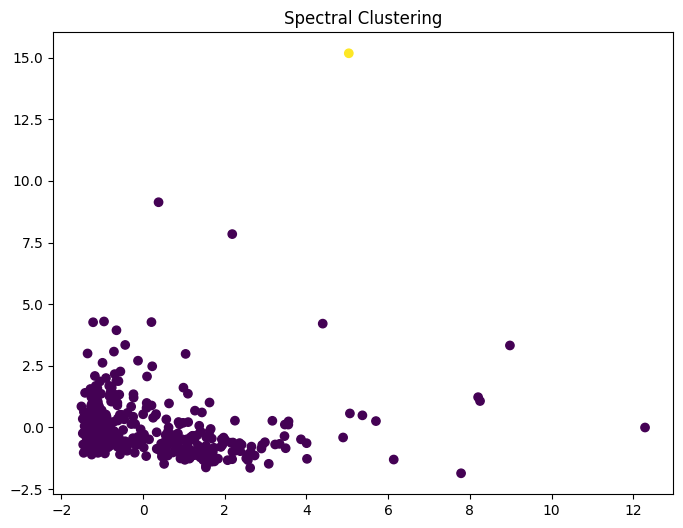

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=spectral_labels
)

plt.title("Spectral Clustering")
plt.show()

**Final Conclusion Cell**

In [53]:
print("\nPROJECT CONCLUSION")
print("-"*50)

print(
    f"The best clustering algorithm for this dataset "
    f"is {best_model['Algorithm']} "
    f"with a Silhouette Score of "
    f"{round(best_model['Silhouette'],4)}"
)


PROJECT CONCLUSION
--------------------------------------------------
The best clustering algorithm for this dataset is Spectral with a Silhouette Score of 0.8264


why spectral algorithm is better?
Spectral Clustering performed better than the other algorithms because it was able to capture the underlying structure of the dataset more effectively, resulting in more compact and well-separated clusters. This is reflected by its higher Silhouette Score compared to the other models.
(Silhouette Score is considered one of the best clustering evaluation metrics because it measures how similar a data point is to its own cluster compared to other clusters. A higher Silhouette Score indicates that clusters are compact, well-separated, and clearly distinguishable, making it useful for comparing the performance of different clustering algorithms.)